In [1]:
# Install / verify dependencies (Colab already has these, but just in case)
!pip install -q torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## Dataset

The dataset is a small corpus of sentences about sequence modeling and deep learning.

In [3]:
# ── Dataset ──────────────────────────────────────────────────────────────────
corpus = [
    "machine learning models learn patterns from data",
    "sequence models process data step by step",
    "recurrent neural networks are designed for sequential tasks",
    "rnn models maintain hidden states across time steps",
    "long short term memory networks solve long dependency problems",
    "lstm uses gates to control information flow",
    "gru models simplify the lstm architecture",
    "sequence prediction is useful in many applications",
    "language modeling predicts the next word in a sentence",
    "speech recognition processes audio sequences",
    "time series forecasting predicts future values",
    "music generation creates new melodies",
    "generative models learn probability distributions",
    "they generate new samples similar to training data",
    "sequence generation is widely used in artificial intelligence",
    "deep learning improves sequence modeling performance",
]

print(f"Total sentences: {len(corpus)}")
print(f"Sample: '{corpus[0]}'")

Total sentences: 16
Sample: 'machine learning models learn patterns from data'


---
## Shared Preprocessing

We build a word-level vocabulary used by **both** Component I (LSTM) and Component II (Transformer).

In [4]:
# ── Word-Level Tokenisation & Vocabulary ─────────────────────────────────────

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
SOS_TOKEN = '<SOS>'   # start of sentence
EOS_TOKEN = '<EOS>'   # end of sentence

def build_vocab(sentences):
    """Build word → index and index → word mappings."""
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1, SOS_TOKEN: 2, EOS_TOKEN: 3}
    for sentence in sentences:
        for word in sentence.split():
            if word not in vocab:
                vocab[word] = len(vocab)
    idx2word = {v: k for k, v in vocab.items()}
    return vocab, idx2word

vocab, idx2word = build_vocab(corpus)
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE}")
print("Sample vocab entries:", list(vocab.items())[:10])

Vocabulary size: 90
Sample vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('<SOS>', 2), ('<EOS>', 3), ('machine', 4), ('learning', 5), ('models', 6), ('learn', 7), ('patterns', 8), ('from', 9)]


In [5]:
def encode(sentence, vocab):
    """Convert a sentence string to a list of token indices."""
    return [vocab.get(w, vocab[UNK_TOKEN]) for w in sentence.split()]

def decode(indices, idx2word):
    """Convert a list of indices back to a sentence string."""
    special = {PAD_TOKEN, SOS_TOKEN, EOS_TOKEN}
    return ' '.join(idx2word[i] for i in indices if idx2word[i] not in special)


# ── Build (input, target) pairs for next-word prediction ─────────────────────
# Input:  tokens[0 .. n-2]
# Target: tokens[1 .. n-1]

def make_ngram_pairs(sentences, vocab, seq_len=5):
    """Sliding-window pairs for LSTM training."""
    inputs, targets = [], []
    for sentence in sentences:
        tokens = encode(sentence, vocab)
        for i in range(len(tokens) - seq_len):
            inputs.append(tokens[i : i + seq_len])
            targets.append(tokens[i + seq_len])    # predict the next token
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

SEQ_LEN = 4   # context window for LSTM
X, Y = make_ngram_pairs(corpus, vocab, SEQ_LEN)
print(f"Training pairs: {X.shape[0]}")
print(f"Sample input : {X[0].tolist()} → {[idx2word[i.item()] for i in X[0]]}")
print(f"Sample target: {Y[0].item()} → {idx2word[Y[0].item()]}")

Training pairs: 47
Sample input : [4, 5, 6, 7] → ['machine', 'learning', 'models', 'learn']
Sample target: 8 → patterns


In [6]:
# ── Task 4: LSTM Model Definition ────────────────────────────────────────────

class LSTMLanguageModel(nn.Module):
    """
    Simple LSTM-based language model:
      Embedding → LSTM stack → Linear → softmax (via CrossEntropyLoss)
    """
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)             # (batch, seq, embed)
        out, hidden = self.lstm(emb, hidden) # out: (batch, seq, hidden)
        logits = self.fc(out[:, -1, :])     # use last timestep → (batch, vocab)
        return logits, hidden


lstm_model = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=128,
    num_layers=2,
    dropout=0.3
).to(device)

print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nTotal parameters: {total_params:,}")

LSTMLanguageModel(
  (embedding): Embedding(90, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=90, bias=True)
)

Total parameters: 248,794


In [7]:
# ── Task 5: Train the LSTM ────────────────────────────────────────────────────

from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16
EPOCHS     = 200
LR         = 1e-3

dataset    = TensorDataset(X.to(device), Y.to(device))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(lstm_model.parameters(), lr=LR)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

lstm_model.train()
loss_history = []

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for xb, yb in dataloader:
        optimizer.zero_grad()
        logits, _ = lstm_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)   # gradient clipping
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    scheduler.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")

print("\nLSTM training complete!")

Epoch  20/200 | Loss: 1.7246 | LR: 0.00100
Epoch  40/200 | Loss: 0.2332 | LR: 0.00100
Epoch  60/200 | Loss: 0.0807 | LR: 0.00050
Epoch  80/200 | Loss: 0.0529 | LR: 0.00050
Epoch 100/200 | Loss: 0.0368 | LR: 0.00025
Epoch 120/200 | Loss: 0.0313 | LR: 0.00025
Epoch 140/200 | Loss: 0.0277 | LR: 0.00025
Epoch 160/200 | Loss: 0.0242 | LR: 0.00013
Epoch 180/200 | Loss: 0.0233 | LR: 0.00013
Epoch 200/200 | Loss: 0.0210 | LR: 0.00006

LSTM training complete!


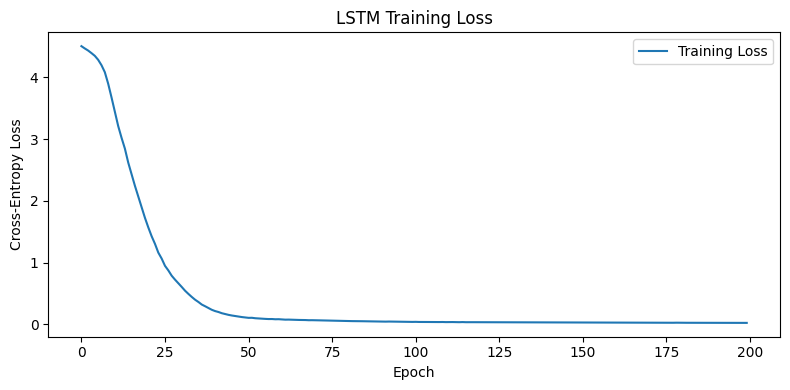

In [8]:
# Plot loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('LSTM Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Task 6: Generate Sequences with LSTM ─────────────────────────────────────

def generate_lstm(model, seed_text, vocab, idx2word, max_words=15, temperature=1.0):
    """
    Generate text word by word from a seed phrase.
    temperature < 1.0 → more deterministic; temperature > 1.0 → more random.
    """
    model.eval()
    words = seed_text.lower().split()
    tokens = [vocab.get(w, vocab[UNK_TOKEN]) for w in words]

    # pad / truncate to SEQ_LEN
    if len(tokens) < SEQ_LEN:
        tokens = [vocab[PAD_TOKEN]] * (SEQ_LEN - len(tokens)) + tokens
    else:
        tokens = tokens[-SEQ_LEN:]

    generated = list(words)
    hidden = None

    with torch.no_grad():
        for _ in range(max_words):
            inp = torch.tensor([tokens], dtype=torch.long).to(device)  # (1, seq_len)
            logits, hidden = model(inp, hidden)
            logits = logits / temperature
            probs  = torch.softmax(logits, dim=-1).squeeze()
            next_idx = torch.multinomial(probs, 1).item()
            next_word = idx2word[next_idx]
            if next_word in {PAD_TOKEN, UNK_TOKEN}:
                continue
            generated.append(next_word)
            tokens = tokens[1:] + [next_idx]   # slide window

    return ' '.join(generated)


# ── Expected Output: Generated Sequence Samples ───────────────────────────────
seeds = [
    "machine learning models",
    "lstm uses gates",
    "sequence generation is",
    "deep learning improves",
]

print("=" * 60)
print(" LSTM Generated Sequences")
print("=" * 60)
for seed in seeds:
    print(f"\n  Seed   : '{seed}'")
    for temp in [0.5, 1.0, 1.5]:
        out = generate_lstm(lstm_model, seed, vocab, idx2word, max_words=10, temperature=temp)
        print(f"  Temp={temp}: {out}")
print("\n" + "=" * 60)

 LSTM Generated Sequences

  Seed   : 'machine learning models'
  Temp=0.5: machine learning models patterns patterns patterns patterns from from from from data data
  Temp=1.0: machine learning models patterns patterns patterns patterns from patterns from from flow data
  Temp=1.5: machine learning models patterns patterns by patterns lstm from from information information from

  Seed   : 'lstm uses gates'
  Temp=0.5: lstm uses gates control control control control information information information information flow flow
  Temp=1.0: lstm uses gates control control control control control information information information sequences intelligence
  Temp=1.5: lstm uses gates control control control control in problems information information lstm control

  Seed   : 'sequence generation is'
  Temp=0.5: sequence generation is used used used used used used in used in in
  Temp=1.0: sequence generation is used used used used used in used used used in
  Temp=1.5: sequence generation is us

In [10]:
# ── Task 2: Full-sentence tokenisation for Transformer ───────────────────────
# For the Transformer we feed the full sentence and predict each next token.

def make_transformer_dataset(sentences, vocab, max_len=20):
    """
    Returns (src, tgt) tensors.
    src = <SOS> + sentence tokens (padded to max_len)
    tgt = sentence tokens + <EOS> (padded to max_len)
    """
    srcs, tgts = [], []
    for s in sentences:
        toks = [vocab[SOS_TOKEN]] + encode(s, vocab) + [vocab[EOS_TOKEN]]
        # truncate
        toks = toks[:max_len + 1]
        src  = toks[:-1]  # input  (drop last)
        tgt  = toks[1:]   # target (drop first)
        # pad
        pad_len = max_len - len(src)
        src += [vocab[PAD_TOKEN]] * pad_len
        tgt += [vocab[PAD_TOKEN]] * pad_len
        srcs.append(src)
        tgts.append(tgt)
    return torch.tensor(srcs, dtype=torch.long), torch.tensor(tgts, dtype=torch.long)


MAX_SEQ_LEN = 18
Xt, Yt = make_transformer_dataset(corpus, vocab, max_len=MAX_SEQ_LEN)
print(f"Transformer dataset shape: src={Xt.shape}, tgt={Yt.shape}")
print(f"Sample src: {[idx2word[i] for i in Xt[0].tolist()]}")
print(f"Sample tgt: {[idx2word[i] for i in Yt[0].tolist()]}")

Transformer dataset shape: src=torch.Size([16, 18]), tgt=torch.Size([16, 18])
Sample src: ['<SOS>', 'machine', 'learning', 'models', 'learn', 'patterns', 'from', 'data', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Sample tgt: ['machine', 'learning', 'models', 'learn', 'patterns', 'from', 'data', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']


In [11]:
# ── Task 3: Positional Encoding ───────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding (Vaswani et al., 2017).
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)          # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# Quick sanity check
pe_test = PositionalEncoding(d_model=64, max_len=50)
dummy   = torch.zeros(2, 10, 64)
print("PE output shape:", pe_test(dummy).shape)   # (2, 10, 64)

PE output shape: torch.Size([2, 10, 64])


In [12]:
# ── Task 4: Transformer Language Model ───────────────────────────────────────

class TransformerLanguageModel(nn.Module):
    """
    Decoder-only Transformer (GPT-style) for language modelling.
    Architecture:
      Embedding + PositionalEncoding
      → N × TransformerDecoderLayer (with causal mask)
      → Linear head → vocab logits
    """
    def __init__(self, vocab_size, d_model=64, nhead=4,
                 num_layers=2, dim_ff=256, dropout=0.1, max_len=500):
        super().__init__()
        self.d_model    = d_model
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc    = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        decoder_layer   = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)

    def _causal_mask(self, size):
        """Upper-triangular mask so position i cannot attend to j > i."""
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        return mask.to(device)

    def forward(self, src, src_key_padding_mask=None):
        """
        src: (batch, seq_len)  — token indices
        Returns logits: (batch, seq_len, vocab_size)
        """
        seq_len = src.size(1)
        causal  = self._causal_mask(seq_len)          # (seq_len, seq_len)

        emb = self.embedding(src) * math.sqrt(self.d_model)  # scale
        emb = self.pos_enc(emb)                               # (batch, seq, d_model)

        # Decoder-only: memory = emb (self-attention only via causal mask)
        out = self.transformer(
            tgt=emb,
            memory=emb,
            tgt_mask=causal,
            memory_mask=causal,
            tgt_key_padding_mask=src_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        logits = self.fc_out(out)   # (batch, seq_len, vocab_size)
        return logits


transformer_model = TransformerLanguageModel(
    vocab_size=VOCAB_SIZE,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_ff=256,
    dropout=0.1,
    max_len=MAX_SEQ_LEN + 10
).to(device)

print(transformer_model)
total_tf = sum(p.numel() for p in transformer_model.parameters())
print(f"\nTotal parameters: {total_tf:,}")

TransformerLanguageModel(
  (embedding): Embedding(90, 64, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerDecoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, 

In [13]:
# ── Task 5: Train the Transformer ────────────────────────────────────────────

BATCH_SIZE_TF = 8
EPOCHS_TF     = 300
LR_TF         = 5e-4

dataset_tf    = TensorDataset(Xt.to(device), Yt.to(device))
loader_tf     = DataLoader(dataset_tf, batch_size=BATCH_SIZE_TF, shuffle=True)

criterion_tf  = nn.CrossEntropyLoss(ignore_index=vocab[PAD_TOKEN])
optimizer_tf  = optim.Adam(transformer_model.parameters(), lr=LR_TF)
scheduler_tf  = optim.lr_scheduler.CosineAnnealingLR(optimizer_tf, T_max=EPOCHS_TF)

transformer_model.train()
tf_loss_history = []

for epoch in range(1, EPOCHS_TF + 1):
    epoch_loss = 0.0
    for xb, yb in loader_tf:
        optimizer_tf.zero_grad()
        # padding mask: True where token == PAD
        pad_mask = (xb == vocab[PAD_TOKEN])
        logits   = transformer_model(xb, src_key_padding_mask=pad_mask)
        # logits: (batch, seq_len, vocab_size) → reshape for loss
        loss = criterion_tf(
            logits.reshape(-1, VOCAB_SIZE),
            yb.reshape(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer_tf.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader_tf)
    tf_loss_history.append(avg_loss)
    scheduler_tf.step()

    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS_TF} | Loss: {avg_loss:.4f}")

print("\nTransformer training complete!")

Epoch  30/300 | Loss: 3.1169
Epoch  60/300 | Loss: 2.2884
Epoch  90/300 | Loss: 1.6268
Epoch 120/300 | Loss: 1.3035
Epoch 150/300 | Loss: 1.0423
Epoch 180/300 | Loss: 0.9063
Epoch 210/300 | Loss: 0.7744
Epoch 240/300 | Loss: 0.7805
Epoch 270/300 | Loss: 0.7995
Epoch 300/300 | Loss: 0.7245

Transformer training complete!


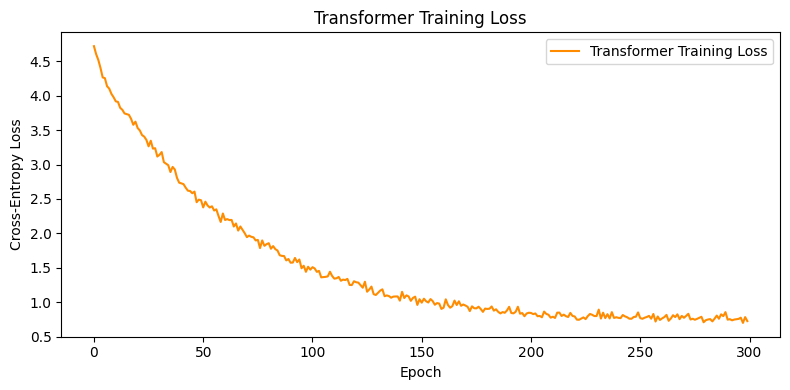

In [14]:
# Plot Transformer loss
plt.figure(figsize=(8, 4))
plt.plot(tf_loss_history, label='Transformer Training Loss', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ── Expected Output: Generate with Transformer ────────────────────────────────

def generate_transformer(model, seed_text, vocab, idx2word, max_new_tokens=15, temperature=1.0):
    """
    Auto-regressively generate tokens from a seed phrase.
    """
    model.eval()
    tokens = [vocab[SOS_TOKEN]] + [vocab.get(w, vocab[UNK_TOKEN])
                                    for w in seed_text.lower().split()]

    with torch.no_grad():
        for _ in range(max_new_tokens):
            inp    = torch.tensor([tokens], dtype=torch.long).to(device)
            logits = model(inp)                    # (1, seq_len, vocab_size)
            next_logits = logits[0, -1, :] / temperature  # last position
            probs  = torch.softmax(next_logits, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()
            if next_idx == vocab[EOS_TOKEN]:
                break
            tokens.append(next_idx)

    return decode(tokens, idx2word)


print("=" * 60)
print(" Transformer Generated Sequences")
print("=" * 60)
for seed in seeds:
    print(f"\n  Seed   : '{seed}'")
    for temp in [0.5, 1.0, 1.5]:
        out = generate_transformer(transformer_model, seed, vocab, idx2word,
                                   max_new_tokens=12, temperature=temp)
        print(f"  Temp={temp}: {out}")
print("\n" + "=" * 60)

 Transformer Generated Sequences

  Seed   : 'machine learning models'
  Temp=0.5: machine learning models learn patterns from data
  Temp=1.0: machine learning models learn patterns from data
  Temp=1.5: machine learning models learn step by data distributions

  Seed   : 'lstm uses gates'
  Temp=0.5: lstm uses gates to control information flow
  Temp=1.0: lstm uses gates to control information
  Temp=1.5: lstm uses gates to many

  Seed   : 'sequence generation is'
  Temp=0.5: sequence generation is is is is is widely used in artificial intelligence
  Temp=1.0: sequence generation is widely new networks
  Temp=1.5: sequence generation is useful data

  Seed   : 'deep learning improves'
  Temp=0.5: deep learning improves sequence modeling performance
  Temp=1.0: deep learning improves improves sequence modeling performance
  Temp=1.5: deep learning improves intelligence control in training samples tasks new rnn gru uses performance



---
## Comparison: LSTM vs Transformer

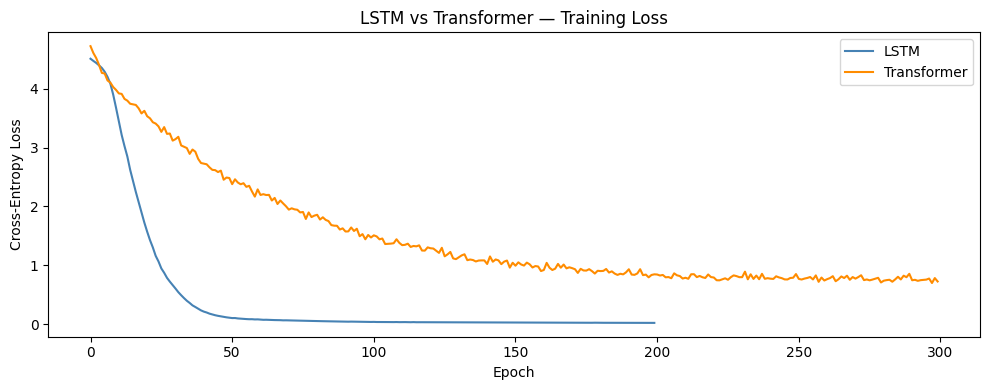

LSTM        — Final loss: 0.0210   Params: 248,794
Transformer — Final loss: 0.7245   Params: 145,114


In [16]:
# Side-by-side loss comparison
plt.figure(figsize=(10, 4))
plt.plot(loss_history,    label='LSTM',        color='steelblue')
plt.plot(tf_loss_history, label='Transformer', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('LSTM vs Transformer — Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

print(f"LSTM        — Final loss: {loss_history[-1]:.4f}   Params: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Transformer — Final loss: {tf_loss_history[-1]:.4f}   Params: {sum(p.numel() for p in transformer_model.parameters()):,}")

In [17]:
# ── Interactive generation cell ───────────────────────────────────────────────
# Modify the variables below and re-run to experiment.

SEED_TEXT   = "sequence models process"   # ← change me
TEMPERATURE = 0.8                         # ← 0.5 (deterministic) – 1.5 (creative)
MAX_WORDS   = 12

lstm_out = generate_lstm(lstm_model, SEED_TEXT, vocab, idx2word,
                         max_words=MAX_WORDS, temperature=TEMPERATURE)
tf_out   = generate_transformer(transformer_model, SEED_TEXT, vocab, idx2word,
                                max_new_tokens=MAX_WORDS, temperature=TEMPERATURE)

print(f"Seed Text   : '{SEED_TEXT}'")
print(f"Temperature : {TEMPERATURE}")
print()
print(f"LSTM        : {lstm_out}")
print(f"Transformer : {tf_out}")

Seed Text   : 'sequence models process'
Temperature : 0.8

LSTM        : sequence models process step step step step step step step step step step step step
Transformer : sequence models process data step by step
